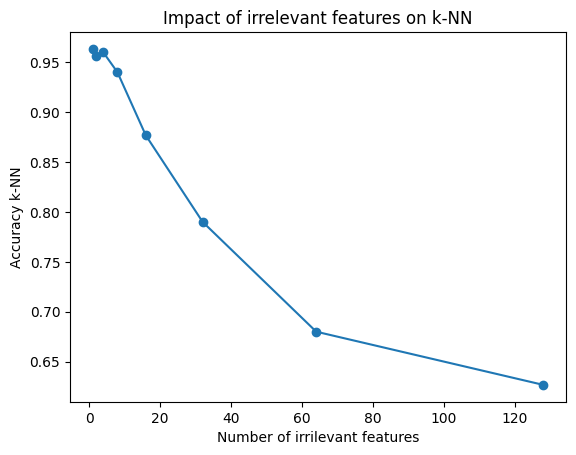

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Dataset base: solo 2 feature informative
X_original, y_original = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

rng = np.random.default_rng(42)

noise_dimensions = [1, 2, 4, 8, 16, 32, 64, 128]
accuracies = []

for n_noise in noise_dimensions:

    # Aggiungiamo feature completamente casuali
    noise = rng.normal(size=(len(X_original), n_noise))

    X_with_noise = np.column_stack([X_original, noise])

    X_train, X_test, y_train, y_test = train_test_split(
        X_with_noise, y_original,
        test_size=0.3,
        random_state=42
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, y_pred)
    )

plt.plot(noise_dimensions, accuracies, marker="o")

plt.xlabel("Number of irrilevant features")
plt.ylabel("Accuracy k-NN")
plt.title("Impact of irrelevant features on k-NN")

plt.show()

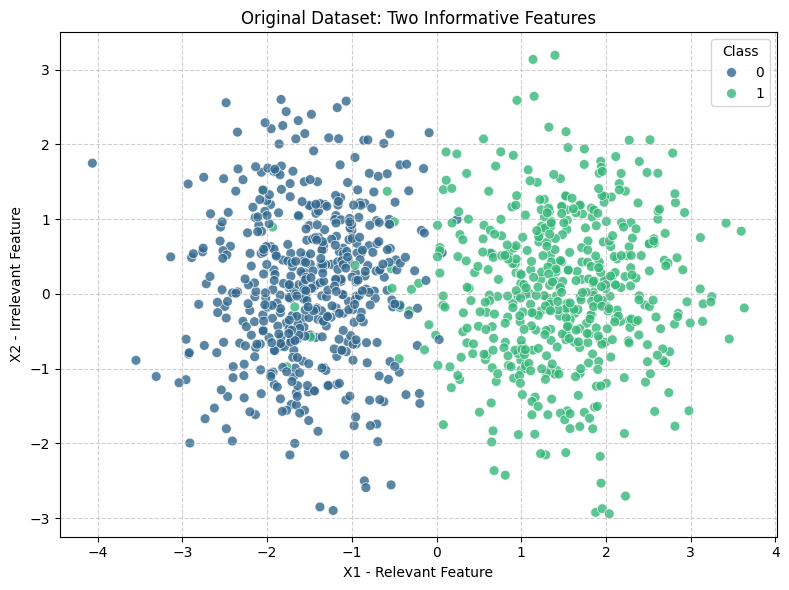

In [2]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_original[:, 0], y=X_original[:, 1], hue=y_original, palette='viridis', s=50, alpha=0.8)
plt.title('Original Dataset: Two Informative Features')
plt.xlabel('X1 - Relevant Feature')
plt.ylabel('X2 - Irrelevant Feature')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

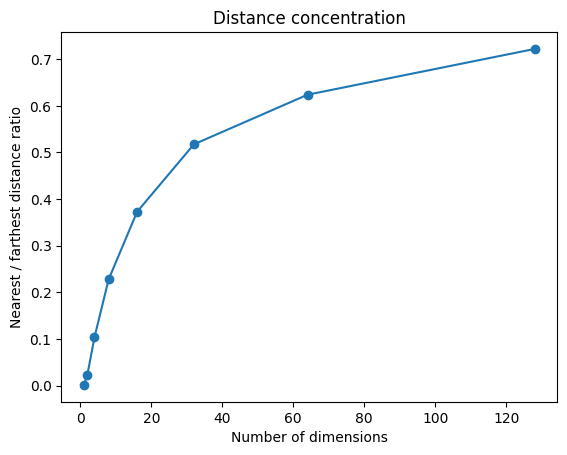

In [3]:
from sklearn.metrics import pairwise_distances

dimensions = [1, 2, 4, 8, 16, 32, 64, 128]
ratios = []

rng = np.random.default_rng(42)

for d in dimensions:

    X = rng.normal(size=(500, d))

    distances = pairwise_distances(X)

    # eliminiamo distanza di ogni punto da se stesso
    distances[distances == 0] = np.nan

    nearest = np.nanmin(distances, axis=1)
    farthest = np.nanmax(distances, axis=1)

    ratios.append(np.mean(nearest / farthest))

plt.plot(dimensions, ratios, marker="o")

plt.xlabel("Number of dimensions")
plt.ylabel("Nearest / farthest distance ratio")
plt.title("Distance concentration")

plt.show()

### Iris Dataset Visualization

Let's load the famous Iris dataset and visualize its features on 2D scatter plots. We will color the points based on their species to observe class separability.

Iris DataFrame Head (Normalized Features):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,0.222222,0.625000,0.067797,0.041667,0,setosa
1,0.166667,0.416667,0.067797,0.041667,0,setosa
2,0.111111,0.500000,0.050847,0.041667,0,setosa
3,0.083333,0.458333,0.084746,0.041667,0,setosa
4,0.194444,0.666667,0.067797,0.041667,0,setosa


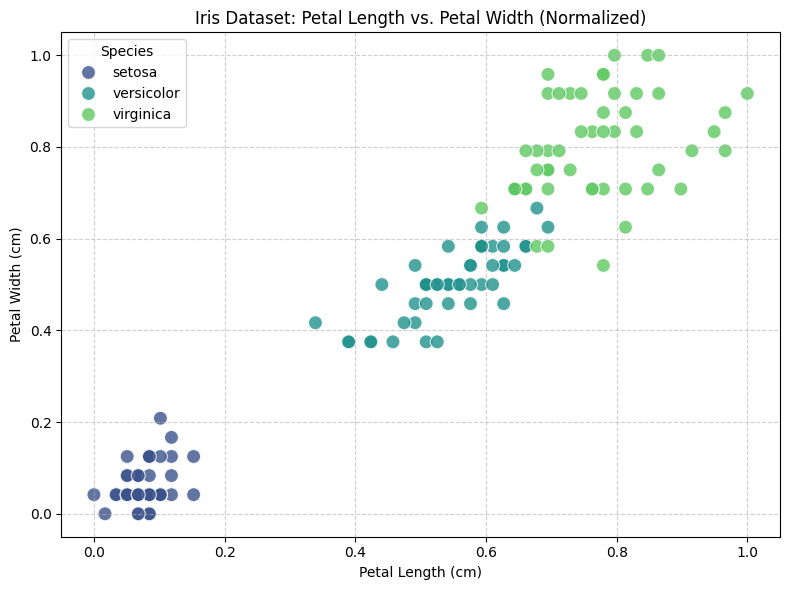

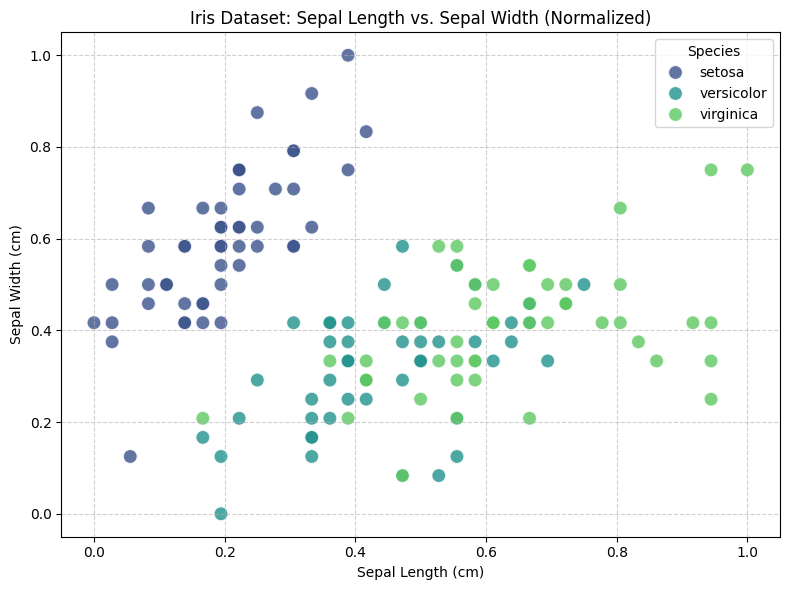

In [4]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame from the Iris data
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species_name'] = iris.target_names[iris.target]

# Normalize all features to [0,1] range
scaler = MinMaxScaler()
iris_df[iris.feature_names] = scaler.fit_transform(iris_df[iris.feature_names])

print("Iris DataFrame Head (Normalized Features):")
display(iris_df.head())

# --- First Scatter Plot: Petal Length vs. Petal Width ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species_name',
    data=iris_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Iris Dataset: Petal Length vs. Petal Width (Normalized)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Species')
plt.tight_layout()
plt.show()

# --- Second Scatter Plot: Sepal Length vs. Sepal Width ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='species_name',
    data=iris_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Iris Dataset: Sepal Length vs. Sepal Width (Normalized)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Species')
plt.tight_layout()
plt.show()

### K-Nearest Neighbors Classification on Iris Dataset

Let's apply KNN (with `k=5`) to the Iris dataset. We will compare the performance using:
1.  All available features.
2.  Only 'petal length (cm)' and 'petal width (cm)'.
3.  Only 'sepal length (cm)' and 'sepal width (cm)'.

--- KNN with All Features ---
Accuracy (All Features): 0.9333
Precision (All Features): 0.9444
Recall (All Features): 0.9333


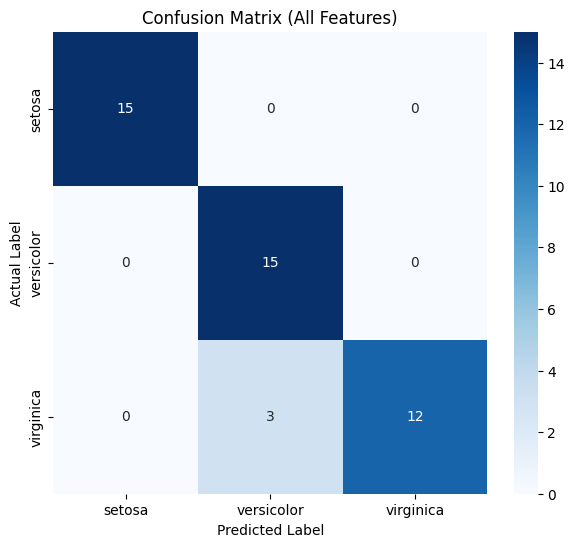

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for KNN
X_iris = iris_df.drop(['species', 'species_name'], axis=1) # All features
y_iris = iris_df['species']

# Split the data into training and testing sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

print("--- KNN with All Features ---")
# Initialize and train the KNN classifier with all features
knn_all_features = KNeighborsClassifier(n_neighbors=3)
knn_all_features.fit(X_train_iris, y_train_iris)

# Make predictions and evaluate
y_pred_all = knn_all_features.predict(X_test_iris)

accuracy_all = accuracy_score(y_test_iris, y_pred_all)
precision_all = precision_score(y_test_iris, y_pred_all, average='weighted')
recall_all = recall_score(y_test_iris, y_pred_all, average='weighted')
conf_matrix_all = confusion_matrix(y_test_iris, y_pred_all)

print(f"Accuracy (All Features): {accuracy_all:.4f}")
print(f"Precision (All Features): {precision_all:.4f}")
print(f"Recall (All Features): {recall_all:.4f}")

plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix_all, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix (All Features)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


--- KNN with Petal Features Only ---
Accuracy (Petal Features): 0.9556
Precision (Petal Features): 0.9556
Recall (Petal Features): 0.9556


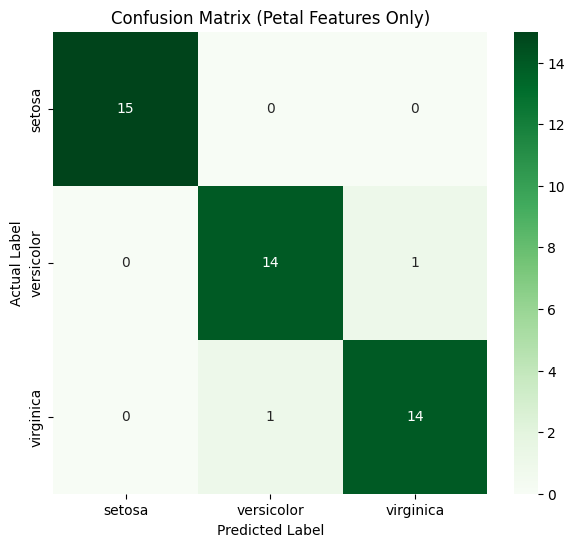

In [6]:
print("\n--- KNN with Petal Features Only ---")
# Select only Petal Length and Petal Width
X_petal_features = iris_df[['petal length (cm)', 'petal width (cm)']]
y_iris = iris_df['species']

# Split the data
X_train_petal, X_test_petal, y_train_petal, y_test_petal = train_test_split(
    X_petal_features, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Initialize and train KNN classifier with petal features
knn_petal_features = KNeighborsClassifier(n_neighbors=3)
knn_petal_features.fit(X_train_petal, y_train_petal)

# Make predictions and evaluate
y_pred_petal = knn_petal_features.predict(X_test_petal)

accuracy_petal = accuracy_score(y_test_petal, y_pred_petal)
precision_petal = precision_score(y_test_petal, y_pred_petal, average='weighted')
recall_petal = recall_score(y_test_petal, y_pred_petal, average='weighted')
conf_matrix_petal = confusion_matrix(y_test_petal, y_pred_petal)

print(f"Accuracy (Petal Features): {accuracy_petal:.4f}")
print(f"Precision (Petal Features): {precision_petal:.4f}")
print(f"Recall (Petal Features): {recall_petal:.4f}")

plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix_petal, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix (Petal Features Only)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


--- KNN with Sepal Features Only ---
Accuracy (Sepal Features): 0.7111
Precision (Sepal Features): 0.7113
Recall (Sepal Features): 0.7111


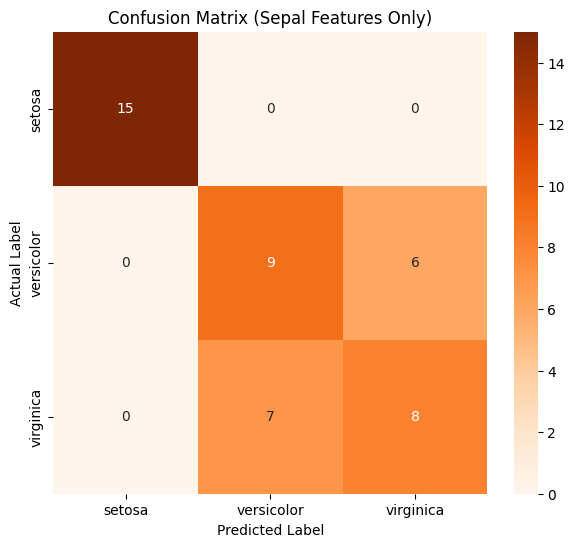

In [7]:
print("\n--- KNN with Sepal Features Only ---")
# Select only Sepal Length and Sepal Width
X_sepal_features = iris_df[['sepal length (cm)', 'sepal width (cm)']]
y_iris = iris_df['species']

# Split the data
X_train_sepal, X_test_sepal, y_train_sepal, y_test_sepal = train_test_split(
    X_sepal_features, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Initialize and train KNN classifier with sepal features
knn_sepal_features = KNeighborsClassifier(n_neighbors=3)
knn_sepal_features.fit(X_train_sepal, y_train_sepal)

# Make predictions and evaluate
y_pred_sepal = knn_sepal_features.predict(X_test_sepal)

accuracy_sepal = accuracy_score(y_test_sepal, y_pred_sepal)
precision_sepal = precision_score(y_test_sepal, y_pred_sepal, average='weighted')
recall_sepal = recall_score(y_test_sepal, y_pred_sepal, average='weighted')
conf_matrix_sepal = confusion_matrix(y_test_sepal, y_pred_sepal)

print(f"Accuracy (Sepal Features): {accuracy_sepal:.4f}")
print(f"Precision (Sepal Features): {precision_sepal:.4f}")
print(f"Recall (Sepal Features): {recall_sepal:.4f}")

plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix_sepal, annot=True, fmt='d', cmap='Oranges',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix (Sepal Features Only)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame from the Iris data (minimal required for this cell)
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species_name'] = iris.target_names[iris.target]

# Prepare data with all features
X_iris_all = iris_df.drop(['species', 'species_name'], axis=1)
y_iris_all = iris_df['species']

# Initialize and train a RandomForestClassifier
# RandomForest provides feature importance scores naturally
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_iris_all, y_iris_all)

# Get feature importances
feature_importances = rf_classifier.feature_importances_
feature_names = X_iris_all.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importances for Iris Dataset ---")
display(importance_df)


--- Feature Importances for Iris Dataset ---


,Feature,Importance
2,petal length (cm),0.436130
3,petal width (cm),0.436065
0,sepal length (cm),0.106128
1,sepal width (cm),0.021678


# `Data Leakeage in feature selection`

In this example...

In [28]:
import numpy as np

# Number of observations
n_observations = 200
# Number of features
n_features = 1000

# Initialize a random number generator for reproducibility
rng = np.random.default_rng(69)

# Generate 1000 completely random features (X1,...X1000)
# Using rng.random() to get values between 0 and 1
X_new_dataset = rng.random((n_observations, n_features))

# Generate 1 random binary target (Y)
# Using rng.integers to get 0 or 1
Y_new_dataset = rng.integers(0, 2, n_observations)

print(f"Shape of new features (X_new_dataset): {X_new_dataset.shape}")
print(f"Shape of new target (Y_new_dataset): {Y_new_dataset.shape}")

print("\nFirst 5 rows of X_new_dataset:")
print(X_new_dataset[:5, :5]) # Displaying first 5 rows and first 5 columns

print("\nFirst 5 values of Y_new_dataset:")
print(Y_new_dataset[:5])

Shape of new features (X_new_dataset): (200, 1000)
Shape of new target (Y_new_dataset): (200,)

First 5 rows of X_new_dataset:
[[0.58037238 0.52685204 0.86496166 0.73476041 0.47658484]
 [0.95663265 0.07106312 0.98079097 0.66098589 0.08458498]
 [0.65692993 0.2789675  0.01434309 0.68641866 0.29770969]
 [0.67001916 0.51826367 0.105255   0.11299163 0.76058105]
 [0.55497927 0.3827037  0.55814125 0.38793922 0.64938777]]

First 5 values of Y_new_dataset:
[1 1 1 0 0]


In [29]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("\n--- Feature Selection using RFE (Wrapper Method) ---")
# Initialize a Decision Tree Classifier as the estimator for RFE
dtc = DecisionTreeClassifier(random_state=42)

# Initialize RFE with the Decision Tree Classifier
# Let's select a small number of features to demonstrate, e.g., 10 features
rfe_selector = RFE(estimator=dtc, n_features_to_select=10, step=1)

# Fit RFE to the entire dataset (X_new_dataset, Y_new_dataset)
rfe_selector.fit(X_new_dataset, Y_new_dataset)

# Get the selected features
X_selected = X_new_dataset[:, rfe_selector.support_]

print(f"Original number of features: {X_new_dataset.shape[1]}")
print(f"Number of features selected by RFE: {X_selected.shape[1]}")

# Split the dataset with selected features into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, Y_new_dataset, test_size=0.3, random_state=42, stratify=Y_new_dataset
)

print("\n--- Training Decision Tree on Selected Features ---")
# Train a Decision Tree model on the training set
dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_train, y_train)

print("\n--- Evaluating the Model on the Test Set ---")
# Predict on the test set
y_pred = dtree_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)


--- Feature Selection using RFE (Wrapper Method) ---
Original number of features: 1000
Number of features selected by RFE: 10

--- Training Decision Tree on Selected Features ---

--- Evaluating the Model on the Test Set ---
Test Accuracy: 0.7833
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.77        29
           1       0.78      0.81      0.79        31

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



In [30]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("\n--- Starting with the full dataset (X_new_dataset, Y_new_dataset) ---")

# 1. Split the entire dataset into training and testing sets first
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_new_dataset, Y_new_dataset, test_size=0.3, random_state=42, stratify=Y_new_dataset
)

print(f"Shape of X_train_full: {X_train_full.shape}")
print(f"Shape of X_test_full: {X_test_full.shape}")

print("\n--- Feature Selection using RFE on the Training Set (Wrapper Method) ---")
# Initialize a Decision Tree Classifier as the estimator for RFE
dtc_rfe = DecisionTreeClassifier(random_state=42)

# Initialize RFE with the Decision Tree Classifier
# Let's select 10 features again for consistency
rfe_selector_train = RFE(estimator=dtc_rfe, n_features_to_select=10, step=1)

# 2. Fit RFE ONLY to the training set (X_train_full, y_train)
rfe_selector_train.fit(X_train_full, y_train)

# 3. Transform both the training and test sets using the RFE selector fitted on training data
X_train_selected = X_train_full[:, rfe_selector_train.support_]
X_test_selected = X_test_full[:, rfe_selector_train.support_]

print(f"Number of features selected by RFE (from training set): {X_train_selected.shape[1]}")
print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

print("\n--- Training Decision Tree on Selected Features (from Training Set) ---")
# 4. Train a Decision Tree model on the feature-selected training set
dtree_model_revisited = DecisionTreeClassifier(random_state=42)
dtree_model_revisited.fit(X_train_selected, y_train)

print("\n--- Evaluating the Model on the Test Set (with selected features) ---")
# 5. Predict on the feature-selected test set
y_pred_revisited = dtree_model_revisited.predict(X_test_selected)

# Evaluate the model
accuracy_revisited = accuracy_score(y_test, y_pred_revisited)
report_revisited = classification_report(y_test, y_pred_revisited)

print(f"Test Accuracy (after correct feature selection): {accuracy_revisited:.4f}")
print("Classification Report (after correct feature selection):")
print(report_revisited)


--- Starting with the full dataset (X_new_dataset, Y_new_dataset) ---
Shape of X_train_full: (140, 1000)
Shape of X_test_full: (60, 1000)

--- Feature Selection using RFE on the Training Set (Wrapper Method) ---
Number of features selected by RFE (from training set): 10
Shape of X_train_selected: (140, 10)
Shape of X_test_selected: (60, 10)

--- Training Decision Tree on Selected Features (from Training Set) ---

--- Evaluating the Model on the Test Set (with selected features) ---
Test Accuracy (after correct feature selection): 0.4333
Classification Report (after correct feature selection):
              precision    recall  f1-score   support

           0       0.43      0.55      0.48        29
           1       0.43      0.32      0.37        31

    accuracy                           0.43        60
   macro avg       0.43      0.44      0.43        60
weighted avg       0.43      0.43      0.43        60



### Custom Dataset Generation

I will now create a new dataset with 7 features and a 3-class target variable, incorporating the specific relationships you requested for each feature:

*   **X1, X2:** Informative features for classifying Y.
*   **X3:** Redundant with X1 (`X3 = X1 / 2 + noise`).
*   **X4:** Irrelevant noise.
*   **X5, X7:** Informative for classifying Y *only* through their XOR interaction.
*   **X6:** Has a nonlinear relationship with X2 (`X6 = X2^2 + noise`).

In [8]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer

# Set a random state for reproducibility
rng = np.random.default_rng(42)
n_samples = 200

# 1. Generate core informative features (X1, X2)
X1 = rng.normal(loc=0, scale=1, size=n_samples)
X2 = rng.normal(loc=0, scale=1, size=n_samples)

# 2. Generate X3: redundant with X1 (X3 = X1 / 2 + noise)
X3 = X1 / 2 + rng.normal(loc=0, scale=0.1, size=n_samples)

# 3. Generate X4: irrelevant noise
X4 = rng.normal(loc=0, scale=1, size=n_samples)
X8 = rng.normal(loc=0, scale=1, size=n_samples)
X9 = rng.normal(loc=0, scale=1, size=n_samples)
X10 = rng.normal(loc=0, scale=1, size=n_samples)

# 4. Generate X5 and X7 for XOR interaction
# Make them binary-like for clear XOR behavior
X5_binary = (rng.random(n_samples) > 0.5).astype(float)
X7_binary = (rng.random(n_samples) > 0.5).astype(float)
# Calculate the XOR interaction: 1 if different, 0 if same
X5_XOR_X7 = (X5_binary != X7_binary).astype(float)

# 5. Generate X6: nonlinear relationship with X2 (X6 = X2^2 + noise)
X6 = X2**2 + rng.normal(loc=0, scale=0.2, size=n_samples)

# 6. Construct the target variable Y (3 values)
# Y will be based on a linear combination of informative features (X1, X2)
# and the XOR interaction (X5_XOR_X7), plus a term from X2's non-linear part.
# Add some inherent noise to Y to make classification non-perfect
Y_latent_score = (
    2.0 * X1                     # X1 is informative
    + 0.5 * X2                   # X2 is informative
    + 0.3 * (X2**2)              # Indirectly makes X6 (which is X2^2 + noise) informative
    + 2.0 * X5_XOR_X7            # X5 and X7 are informative through XOR
    + rng.normal(loc=0, scale=0.8, size=n_samples) # Noise in the target relationship
)

# Discretize Y_latent_score into 3 classes
# Using KBinsDiscretizer to ensure somewhat balanced classes
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile', random_state=42)
Y_custom_dataset = discretizer.fit_transform(Y_latent_score.reshape(-1, 1)).flatten().astype(int)

# 7. Combine all features into X_custom_dataset
X_custom_dataset = np.column_stack([
    X1, X2, X3, X4, X5_binary, X6, X7_binary, X8, X9, X10
])

print(f"Shape of X_custom_dataset: {X_custom_dataset.shape}")
print(f"Shape of Y_custom_dataset: {Y_custom_dataset.shape}")
print(f"Unique values in Y_custom_dataset: {np.unique(Y_custom_dataset)}")

print("\nFirst 5 rows of X_custom_dataset:")
print(X_custom_dataset[:5])

print("\nFirst 5 values of Y_custom_dataset:")
print(Y_custom_dataset[:5])

Shape of X_custom_dataset: (200, 10)
Shape of Y_custom_dataset: (200,)
Unique values in Y_custom_dataset: [0 1 2]

First 5 rows of X_custom_dataset:
[[ 3.04717080e-01  3.37574549e-01  1.34397398e-01  5.15410403e-01
   0.00000000e+00  4.88169540e-02  1.00000000e+00 -8.45045328e-01
  -5.92826460e-02 -1.32254113e+00]
 [-1.03998411e+00  1.40748186e+00 -5.00314443e-01 -5.77538887e-01
   0.00000000e+00  1.91554410e+00  0.00000000e+00 -1.08369883e+00
  -7.29286936e-01 -4.86194131e-01]
 [ 7.50451196e-01  9.05849069e-02  4.57278445e-01  1.27444722e+00
   0.00000000e+00 -2.14088556e-02  0.00000000e+00  3.44604905e-01
  -4.14473066e-01  4.20226709e-01]
 [ 9.40564716e-01  6.43938793e-01  4.30908241e-01 -6.27587536e-01
   0.00000000e+00  3.01962884e-01  0.00000000e+00  3.79280034e-01
   6.33910378e-01 -1.02396707e-01]
 [-1.95103519e+00 -2.05017210e+00 -9.23400869e-01 -6.36615283e-01
   0.00000000e+00  4.11460321e+00  0.00000000e+00  1.28733111e+00
   2.99329120e-03 -6.50563620e-01]]

First 5 values

### Save Custom Dataset to CSV

I will now save the `custom_df` DataFrame, which contains your custom features and target variable, to a CSV file named `FeatureSelection.csv`. You will be prompted to download this file to your local machine.

In [39]:
from google.colab import files

# Define the filename
csv_filename = 'FeatureSelection.csv'

# Save the DataFrame to a CSV file without the index
custom_df.to_csv(csv_filename, index=False)

# Prompt the user to download the file
files.download(csv_filename)

print(f"'{csv_filename}' has been saved and is ready for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'FeatureSelection.csv' has been saved and is ready for download.


### Scatterplot Matrix for Custom Dataset

To visualize the relationships between the features and the target variable, I will generate scatterplot matrices using `seaborn.pairplot`. Since there are 7 features, I will split them into two plots to maintain readability.

First, I'll combine the features and target into a single Pandas DataFrame.

Custom Dataset DataFrame Head:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,0.304717,0.337575,0.134397,0.515410,0.0,0.048817,1.0,-0.845045,-0.059283,-1.322541,2
1,-1.039984,1.407482,-0.500314,-0.577539,0.0,1.915544,0.0,-1.083699,-0.729287,-0.486194,0
2,0.750451,0.090585,0.457278,1.274447,0.0,-0.021409,0.0,0.344605,-0.414473,0.420227,1
3,0.940565,0.643939,0.430908,-0.627588,0.0,0.301963,0.0,0.379280,0.633910,-0.102397,1
4,-1.951035,-2.050172,-0.923401,-0.636615,0.0,4.114603,0.0,1.287331,0.002993,-0.650564,0


<Figure size 1000x800 with 0 Axes>

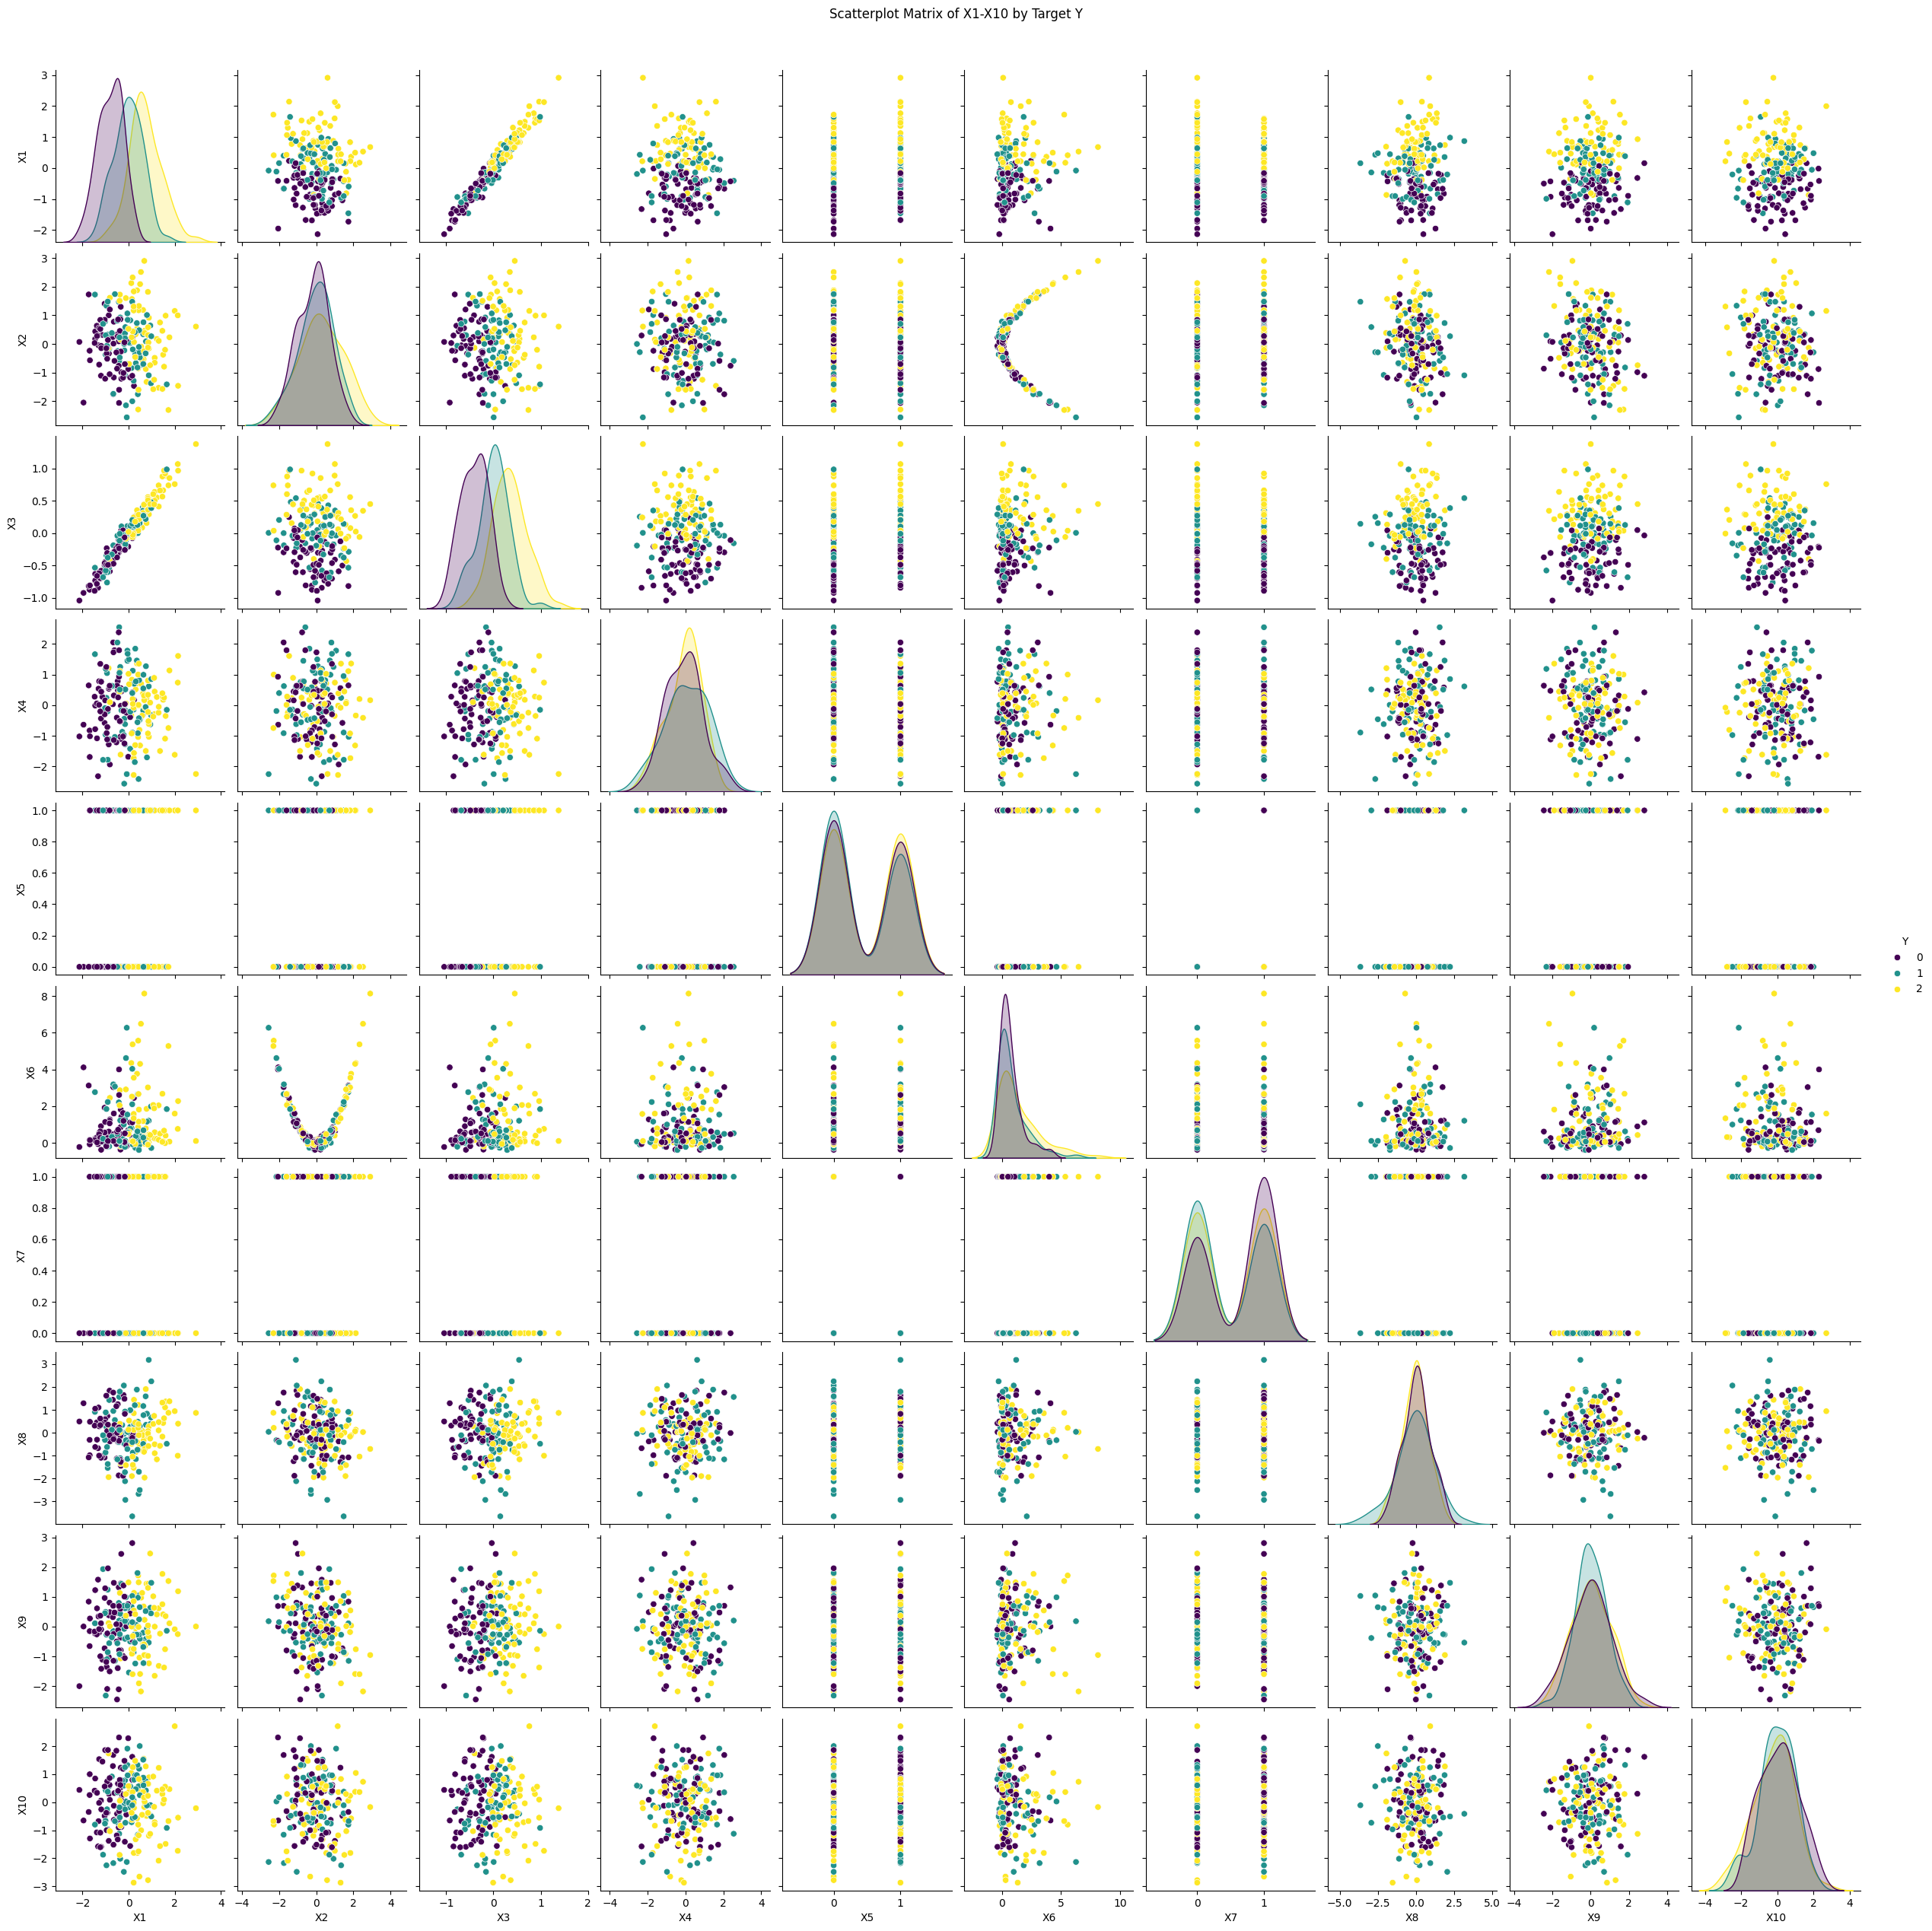

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame from the custom dataset for easier plotting
feature_names = [f'X{i+1}' for i in range(X_custom_dataset.shape[1])]
custom_df = pd.DataFrame(X_custom_dataset, columns=feature_names)
custom_df['Y'] = Y_custom_dataset

print("Custom Dataset DataFrame Head:")
display(custom_df.head())

# Plot 1: Features X1 to X7 and Y
plt.figure(figsize=(10, 8))
sns.pairplot(custom_df, vars=['X1', 'X2', 'X3','X4','X5', 'X6', 'X7', 'X8', 'X9', 'X10'], hue='Y', palette='viridis', diag_kind='kde')
plt.suptitle('Scatterplot Matrix of X1-X10 by Target Y', y=1.02) # Adjust suptitle position
plt.show()

### Box Plots for Each Feature by Target Class

These box plots visualize the distribution of each feature (`X1` to `X10`) across the different classes of the target variable `Y`. This can help identify features that show clear separation between classes, indicating their predictive power.

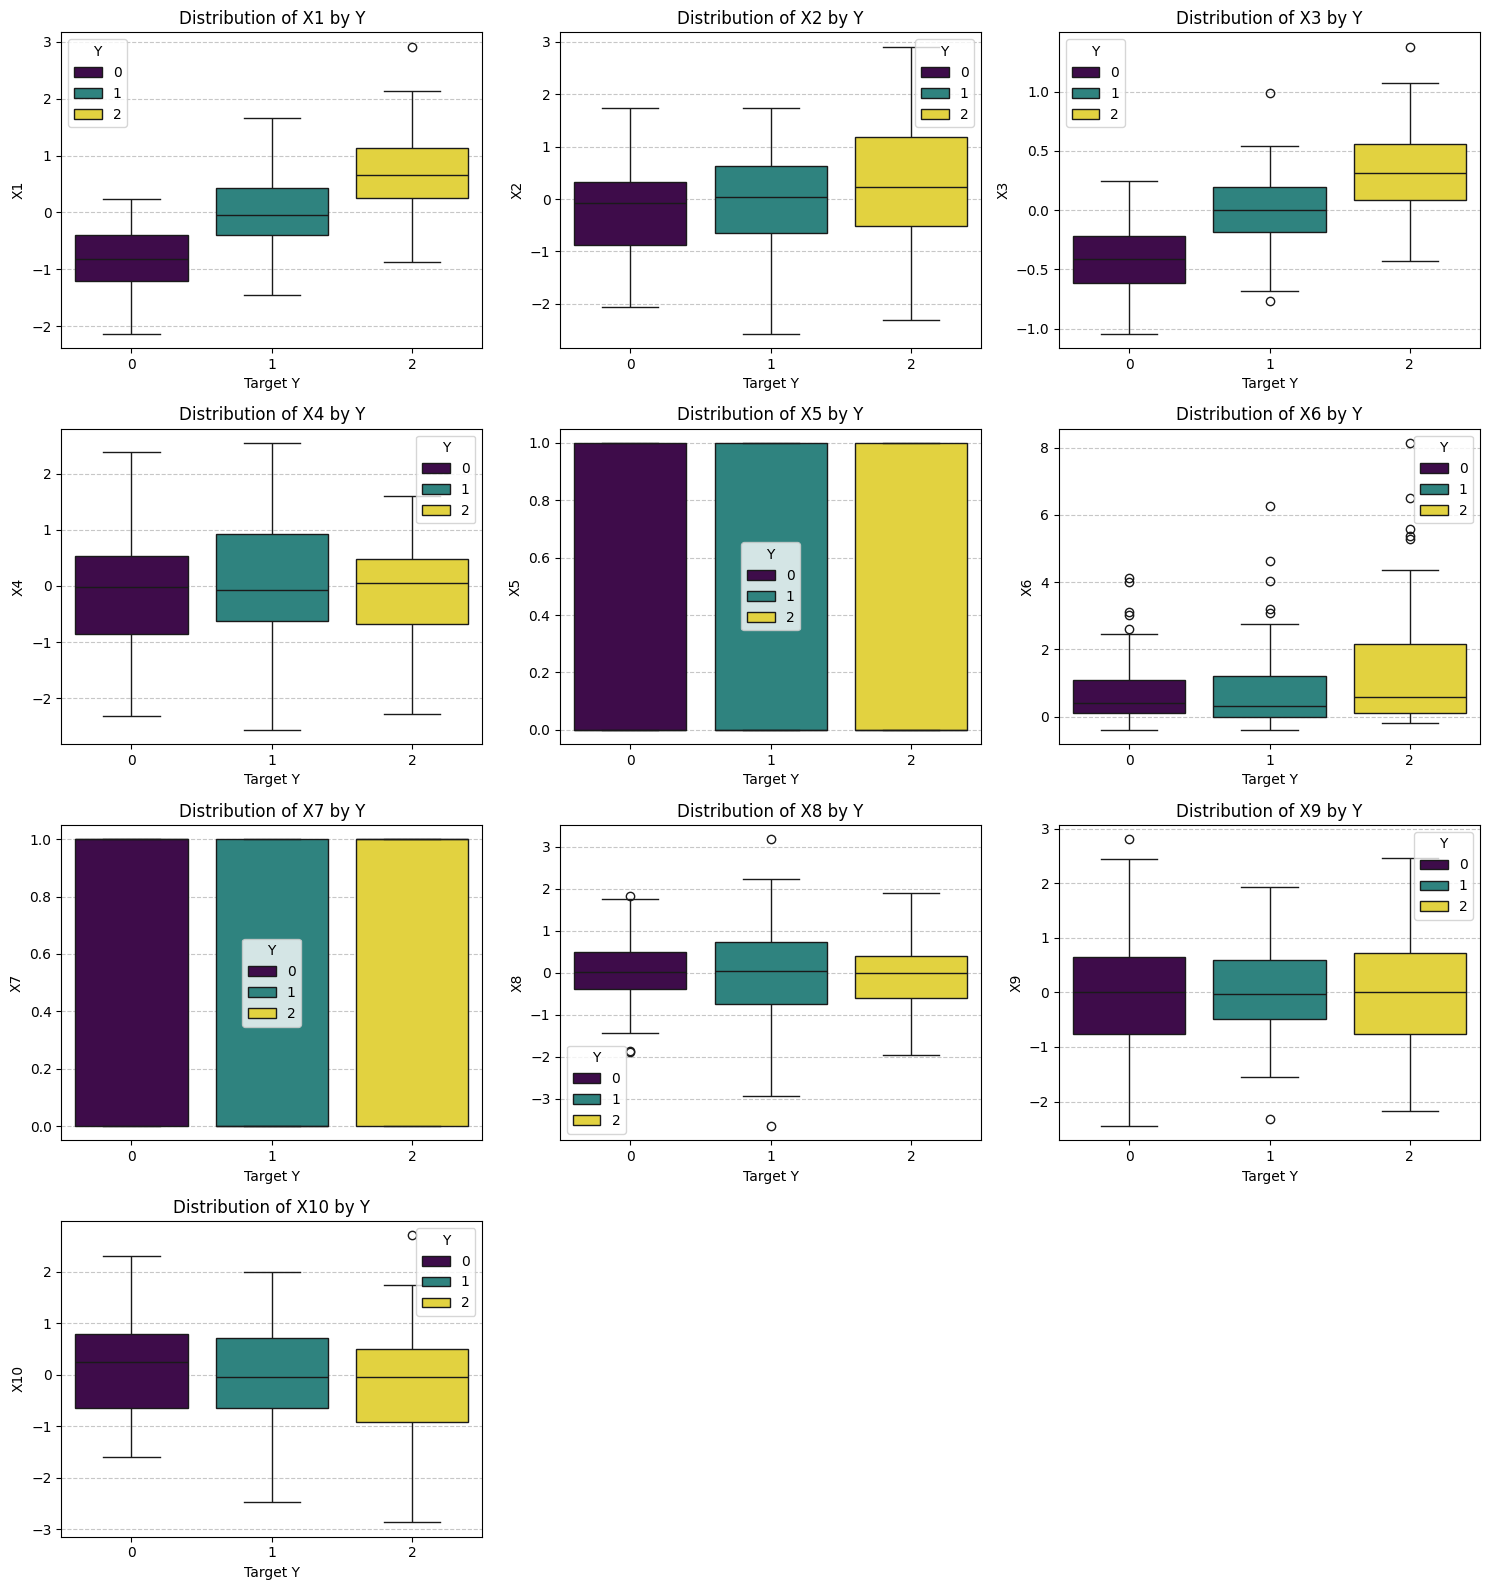

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names (excluding the target 'Y')
feature_columns = custom_df.drop('Y', axis=1).columns

# Determine number of rows and columns for the subplot grid
n_features = len(feature_columns)
n_cols = 3  # For example, 3 columns per row
n_rows = (n_features + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4)) # Adjust figure size dynamically

for i, feature in enumerate(feature_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x='Y', y=feature, data=custom_df, palette='viridis', hue='Y') # Added hue='Y'
    plt.title(f'Distribution of {feature} by Y')
    plt.xlabel('Target Y')
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Feature Selection Method 1: Mutual Information (Univariate Filter)

Mutual Information measures the dependency between two variables. For feature selection, `mutual_info_classif` estimates mutual information between each feature and the target variable. We will select the top features based on their scores.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd
import numpy as np

# --- Data Preparation (Normalization and Train/Test Split) ---
# Separate features (X) and target (Y)
X = custom_df.drop('Y', axis=1).values
Y = custom_df['Y'].values

print("--- Data Preparation ---")
# 1) Normalize the features with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features normalized successfully.")

# 2) Split training set and test set
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.3, random_state=42, stratify=Y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# --- Baseline Model: K-Nearest Neighbors (K-NN) ---
print("\n--- Baseline Model: K-Nearest Neighbors (K-NN) ---")
# 3) Train a K-NN on the training set and test its performance on the test set
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common default
knn_model.fit(X_train, Y_train)

Y_pred_knn = knn_model.predict(X_test)

print(f"Accuracy: {accuracy_score(Y_test, Y_pred_knn):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_knn, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_knn))

# --- Baseline Model: Decision Tree ---
print("\n--- Baseline Model: Decision Tree ---")
# 4) Train a Decision Tree on the training set and test its performance on the test set
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)

Y_pred_dt = dt_model.predict(X_test)

print(f"Accuracy: {accuracy_score(Y_test, Y_pred_dt):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_dt, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_dt))

# Feature importance for Decision Tree
feature_names = custom_df.drop('Y', axis=1).columns.tolist()
feature_importances_dt = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nDecision Tree Feature Importances:")
display(feature_importances_dt)



--- Data Preparation ---
Features normalized successfully.
Training set shape: (140, 10)
Testing set shape: (60, 10)

--- Baseline Model: K-Nearest Neighbors (K-NN) ---
Accuracy: 0.8167
F1-Score (weighted): 0.8203
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        20
           1       0.70      0.80      0.74        20
           2       1.00      0.90      0.95        20

    accuracy                           0.82        60
   macro avg       0.83      0.82      0.82        60
weighted avg       0.83      0.82      0.82        60


--- Baseline Model: Decision Tree ---
Accuracy: 0.5500
F1-Score (weighted): 0.5517
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.55      0.63        20
           1       0.38      0.40      0.39        20
           2       0.58      0.70      0.64        20

    accuracy                           0.55        60
   

,Feature,Importance
0,X1,0.256473
2,X3,0.180793
8,X9,0.130202
1,X2,0.107063
5,X6,0.090663
9,X10,0.085752
3,X4,0.068905
7,X8,0.051576
6,X7,0.028573
4,X5,0.000000


In [11]:
# --- Feature Selection Method 1: Mutual Information (Univariate Filter) ---
print("\n--- Applying Mutual Information Feature Selection ---")

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_train, Y_train, random_state=42)

# Create a DataFrame to display scores
mi_df = pd.DataFrame({
    'Feature': feature_names,
    'Mutual Information Score': mi_scores
}).sort_values(by='Mutual Information Score', ascending=False)

display(mi_df)

# Select the top 4 features based on Mutual Information (as an example)
k_features_mi = 4
selector_mi = SelectKBest(mutual_info_classif, k=k_features_mi)
selector_mi.fit(X_train, Y_train)

X_train_mi_selected = selector_mi.transform(X_train)
X_test_mi_selected = selector_mi.transform(X_test)

# Get the names of the selected features
selected_features_mi = [feature_names[i] for i in selector_mi.get_support(indices=True)]
print(f"\nSelected Features by Mutual Information (top {k_features_mi}): {selected_features_mi}")

print("\n--- Training K-NN on Mutual Information Selected Features ---")
# Train K-NN on the selected features
knn_mi = KNeighborsClassifier(n_neighbors=5)
knn_mi.fit(X_train_mi_selected, Y_train)

Y_pred_mi = knn_mi.predict(X_test_mi_selected)

print("\n--- K-NN Performance with Mutual Information Selected Features ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_mi):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_mi, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_mi))


--- Applying Mutual Information Feature Selection ---


,Feature,Mutual Information Score
2,X3,0.356412
0,X1,0.349573
8,X9,0.087058
1,X2,0.063623
7,X8,0.058489
3,X4,0.032247
5,X6,0.000000
4,X5,0.000000
6,X7,0.000000
9,X10,0.000000



Selected Features by Mutual Information (top 4): ['X1', 'X2', 'X3', 'X9']

--- Training K-NN on Mutual Information Selected Features ---

--- K-NN Performance with Mutual Information Selected Features ---
Accuracy: 0.5500
F1-Score (weighted): 0.5584
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.65      0.59        20
           1       0.33      0.35      0.34        20
           2       0.87      0.65      0.74        20

    accuracy                           0.55        60
   macro avg       0.58      0.55      0.56        60
weighted avg       0.58      0.55      0.56        60



### Feature Selection Method 3: Wrapper Method - K-NN with Sequential Forward Selection (SFS)

Sequential Forward Selection (SFS) is a greedy algorithm that iteratively adds the best performing feature to the selected subset. We will use a K-NN classifier as the estimator for evaluating feature subsets. Note that SFS is not part of `scikit-learn` itself but is commonly found in libraries like `mlxtend`.

Since `mlxtend` might not be pre-installed, I will provide the code to install it if needed.

In [12]:
# Uncomment and run the following line if mlxtend is not installed
#!pip install mlxtend

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

print("\n--- Applying Sequential Forward Selection (SFS) with K-NN ---")

# Initialize the K-NN classifier (estimator for SFS)
knn_sfs = KNeighborsClassifier(n_neighbors=5)

# Initialize SFS
# We'll select 4 features for consistency, and use f_score as scoring for classification
sfs1 = SFS(knn_sfs,
           k_features=4,
           forward=True, # Forward selection
           floating=False,
           verbose=0, # Set to 2 for more verbose output
           scoring='f1_weighted', # Use weighted F1-score for evaluation
           cv=3, # 3-fold cross-validation
           n_jobs=-1) # Use all available cores

# Fit SFS to the training data
sfs1 = sfs1.fit(X_train, Y_train)

# Get the selected features
selected_features_sfs = [feature_names[i] for i in sfs1.k_feature_idx_]
print(f"\nSelected Features by SFS (top {len(sfs1.k_feature_idx_)}): {selected_features_sfs}")

# Transform the training and test sets with the selected features
X_train_sfs_selected = sfs1.transform(X_train)
X_test_sfs_selected = sfs1.transform(X_test)

print("\n--- Training K-NN on SFS Selected Features ---")
# Train K-NN on the SFS selected features
knn_sfs_model = KNeighborsClassifier(n_neighbors=5)
knn_sfs_model.fit(X_train_sfs_selected, Y_train)

Y_pred_sfs = knn_sfs_model.predict(X_test_sfs_selected)

print("\n--- K-NN Performance with SFS Selected Features ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_sfs):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_sfs, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_sfs))

# Display the SFS results (feature performance)
print("\nSFS Feature Selection Results (f1_weighted):")
sfs_results_df = pd.DataFrame.from_dict(sfs1.get_metric_dict()).T
display(sfs_results_df.sort_values(by='avg_score', ascending=False))


--- Applying Sequential Forward Selection (SFS) with K-NN ---

Selected Features by SFS (top 4): ['X1', 'X3', 'X7', 'X10']

--- Training K-NN on SFS Selected Features ---

--- K-NN Performance with SFS Selected Features ---
Accuracy: 0.5500
F1-Score (weighted): 0.5296
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.85      0.74        20
           1       0.33      0.25      0.29        20
           2       0.58      0.55      0.56        20

    accuracy                           0.55        60
   macro avg       0.52      0.55      0.53        60
weighted avg       0.52      0.55      0.53        60


SFS Feature Selection Results (f1_weighted):


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
3,"(0, 2, 9)","[0.6513002364066193, 0.7078689631881122, 0.531...",0.630254,"(0, 2, 9)",0.165372,0.073488,0.051964
4,"(0, 2, 6, 9)","[0.7209634337293912, 0.5809459559641189, 0.517...",0.606432,"(0, 2, 6, 9)",0.191372,0.085042,0.060134
2,"(2, 9)","[0.5722531362200526, 0.6570788265193023, 0.583...",0.604136,"(2, 9)",0.084829,0.037696,0.026655
1,"(2,)","[0.5746578429279632, 0.6118141954617581, 0.567...",0.584555,"(2,)",0.043914,0.019514,0.013799


### Feature Selection Method 4: Wrapper Method - K-NN with Sequential Backward Elimination (SBE)

Sequential Backward Elimination (SBE) is a greedy algorithm that starts with the full set of features and iteratively removes the worst performing feature based on a chosen metric, until the desired number of features is reached. We will again use a K-NN classifier as the estimator.

In [6]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

print("\n--- Applying Sequential Backward Elimination (SBE) with K-NN ---")

# Initialize the K-NN classifier (estimator for SBE)
knn_sbe = KNeighborsClassifier(n_neighbors=5)

# Initialize SBE
# We'll select 4 features for consistency, and use f1_weighted as scoring
sbs1 = SFS(knn_sbe,
           k_features=4,
           forward=False, # Backward selection
           floating=False,
           verbose=0,
           scoring='f1_weighted',
           cv=3,
           n_jobs=-1)

# Fit SBE to the training data
sbs1 = sbs1.fit(X_train, Y_train)

# Get the selected features
selected_features_sbe = [feature_names[i] for i in sbs1.k_feature_idx_]
print(f"\nSelected Features by SBE (top {len(sbs1.k_feature_idx_)}): {selected_features_sbe}")

# Transform the training and test sets with the selected features
X_train_sbe_selected = sbs1.transform(X_train)
X_test_sbe_selected = sbs1.transform(X_test)

print("\n--- Training K-NN on SBE Selected Features ---")
# Train K-NN on the SBE selected features
knn_sbe_model = KNeighborsClassifier(n_neighbors=5)
knn_sbe_model.fit(X_train_sbe_selected, Y_train)

Y_pred_sbe = knn_sbe_model.predict(X_test_sbe_selected)

print("\n--- K-NN Performance with SBE Selected Features ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_sbe):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_sbe, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_sbe))

# Display the SBE results (feature performance)
print("\nSBE Feature Selection Results (f1_weighted):")
sbe_results_df = pd.DataFrame.from_dict(sbs1.get_metric_dict()).T
display(sbe_results_df.sort_values(by='avg_score', ascending=False))


--- Applying Sequential Backward Elimination (SBE) with K-NN ---

Selected Features by SBE (top 4): ['X1', 'X3', 'X5', 'X7']

--- Training K-NN on SBE Selected Features ---

--- K-NN Performance with SBE Selected Features ---
Accuracy: 0.6167
F1-Score (weighted): 0.6095
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.65      0.63        20
           1       0.47      0.40      0.43        20
           2       0.73      0.80      0.76        20

    accuracy                           0.62        60
   macro avg       0.61      0.62      0.61        60
weighted avg       0.61      0.62      0.61        60


SBE Feature Selection Results (f1_weighted):


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
4,"(0, 2, 4, 6)","[0.809488872584984, 0.7058079355951696, 0.7221...",0.745826,"(0, 2, 4, 6)",0.102413,0.04551,0.03218
5,"(0, 1, 2, 4, 6)","[0.7849097085642769, 0.7828868406695955, 0.659...",0.742291,"(0, 1, 2, 4, 6)",0.132427,0.058848,0.041612
6,"(0, 1, 2, 4, 5, 6)","[0.8082693787566814, 0.7289213874663428, 0.664...",0.733948,"(0, 1, 2, 4, 5, 6)",0.132182,0.058739,0.041535
7,"(0, 1, 2, 3, 4, 5, 6)","[0.7855443651481803, 0.6285246668225392, 0.606...",0.673554,"(0, 1, 2, 3, 4, 5, 6)",0.179338,0.079694,0.056352


### Feature Selection Method 5: Wrapper Method - K-NN with Sequential Forward Floating Selection (SFFS)

Sequential Forward Floating Selection (SFFS) is a more advanced variant of SFS. It starts by adding features like SFS, but after each forward step, it also performs backward steps, removing features that are no longer contributing effectively, until the performance drops. This 'floating' behavior allows for a more optimal search through feature subsets.

In [7]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

print("\n--- Applying Sequential Forward Floating Selection (SFFS) with K-NN ---")

# Initialize the K-NN classifier (estimator for SFFS)
knn_sffs = KNeighborsClassifier(n_neighbors=5)

# Initialize SFFS
# We'll select 4 features for consistency, and use f1_weighted as scoring
sffs1 = SFS(knn_sffs,
            k_features=4,
            forward=True, # Forward selection
            floating=True, # Enable floating for better exploration
            verbose=0,
            scoring='f1_weighted',
            cv=3,
            n_jobs=-1)

# Fit SFFS to the training data
sffs1 = sffs1.fit(X_train, Y_train)

# Get the selected features
selected_features_sffs = [feature_names[i] for i in sffs1.k_feature_idx_]
print(f"\nSelected Features by SFFS (top {len(sffs1.k_feature_idx_)}): {selected_features_sffs}")

# Transform the training and test sets with the selected features
X_train_sffs_selected = sffs1.transform(X_train)
X_test_sffs_selected = sffs1.transform(X_test)

print("\n--- Training K-NN on SFFS Selected Features ---")
# Train K-NN on the SFFS selected features
knn_sffs_model = KNeighborsClassifier(n_neighbors=5)
knn_sffs_model.fit(X_train_sffs_selected, Y_train)

Y_pred_sffs = knn_sffs_model.predict(X_test_sffs_selected)

print("\n--- K-NN Performance with SFFS Selected Features ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_sffs):.4f}")
print(f"F1-Score (weighted): {f1_score(Y_test, Y_pred_sffs, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(Y_test, Y_pred_sffs))

# Display the SFFS results (feature performance)
print("\nSFFS Feature Selection Results (f1_weighted):")
sffs_results_df = pd.DataFrame.from_dict(sffs1.get_metric_dict()).T
display(sffs_results_df.sort_values(by='avg_score', ascending=False))


--- Applying Sequential Forward Floating Selection (SFFS) with K-NN ---

Selected Features by SFFS (top 4): ['X1', 'X3', 'X5', 'X7']

--- Training K-NN on SFFS Selected Features ---

--- K-NN Performance with SFFS Selected Features ---
Accuracy: 0.6167
F1-Score (weighted): 0.6095
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.65      0.63        20
           1       0.47      0.40      0.43        20
           2       0.73      0.80      0.76        20

    accuracy                           0.62        60
   macro avg       0.61      0.62      0.61        60
weighted avg       0.61      0.62      0.61        60


SFFS Feature Selection Results (f1_weighted):


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
4,"(0, 2, 4, 6)","[0.809488872584984, 0.7058079355951696, 0.7221...",0.745826,"(0, 2, 4, 6)",0.102413,0.04551,0.03218
3,"(2, 4, 6)","[0.7857157020766705, 0.6964956195244055, 0.671...",0.717876,"(2, 4, 6)",0.11038,0.04905,0.034684
2,"(1, 2)","[0.7382966081339047, 0.6426239054928142, 0.678...",0.68644,"(1, 2)",0.08882,0.03947,0.027909
1,"(2,)","[0.7002601213899821, 0.426995384442193, 0.6360...",0.587769,"(2,)",0.262539,0.116667,0.082496
